# Week 1 Tutorial — Your First ML Model + Linear Algebra in Action

**Run every cell. Break things. Change numbers and see what happens.**

Parts:
1. Linear algebra fundamentals in NumPy
2. Your first classifier (Iris dataset)
3. Build a second model on real-world data

---

## Setup

Install dependencies if needed:
```bash
pip install numpy pandas scikit-learn matplotlib seaborn
```

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Reproducibility
np.random.seed(42)
print('Setup complete.')

Setup complete.


---
## Part 1 — Linear Algebra in NumPy

Before touching ML, get comfortable with vectors and matrices. Every dataset you train on IS a matrix.

In [8]:
# --- Vectors ---
# Think: one patient's medical record
patient_a = np.array([45, 180, 120, 200])  # age, weight, blood_pressure, cholesterol
patient_b = np.array([30, 160, 110, 180])

print('patient_a:', patient_a)
print('Shape:', patient_a.shape)         # (4,) = 4-dimensional vector
print('Dtype:', patient_a.dtype)

patient_a: [ 45 180 120 200]
Shape: (4,)
Dtype: int64


In [9]:
# Vector operations
print('Addition:         ', patient_a + patient_b)
print('Difference:       ', patient_a - patient_b)
print('Scale (×0.5):     ', 0.5 * patient_a)

# Dot product — measures how "similar" two vectors are
# In a linear model: prediction = dot(weights, features)
dot = np.dot(patient_a, patient_b)
print('Dot product:      ', dot)

# Magnitude (length of the vector)
mag_a = np.linalg.norm(patient_a)
print('Magnitude of a:   ', round(mag_a, 2))

Addition:          [ 75 340 230 380]
Difference:        [15 20 10 20]
Scale (×0.5):      [ 22.5  90.   60.  100. ]
Dot product:       79350
Magnitude of a:    298.04


In [10]:
# Cosine similarity — used in ML to compare vectors (e.g., text embeddings)
# Value of 1 = identical direction, 0 = orthogonal, -1 = opposite
cosine_sim = dot / (np.linalg.norm(patient_a) * np.linalg.norm(patient_b))
print(f'Cosine similarity between patients: {cosine_sim:.4f}')
# These patients are very similar (close to 1.0)

Cosine similarity between patients: 0.9992


In [11]:
# --- Matrices ---
# Think: your entire dataset (N patients × M features)
X = np.array([
    [45, 180, 120, 200],   # patient 1
    [30, 160, 110, 180],   # patient 2
    [55, 200, 135, 240],   # patient 3
    [25, 140,  95, 160],   # patient 4
])

print('Dataset matrix X:')
print(X)
print('Shape:', X.shape)   # (4 samples, 4 features)

Dataset matrix X:
[[ 45 180 120 200]
 [ 30 160 110 180]
 [ 55 200 135 240]
 [ 25 140  95 160]]
Shape: (4, 4)


In [13]:
# Slicing — you'll do this constantly
print('First patient (row 0):      ', X[0])       # one sample
print('All ages (column 0):        ', X[:, 0])    # one feature across all samples
print('First 2 patients:           \n', X[:2])

First patient (row 0):       [ 45 180 120 200]
All ages (column 0):         [45 30 55 25]
First 2 patients:           
 [[ 45 180 120 200]
 [ 30 160 110 180]]


In [14]:
# Matrix multiplication — the core operation in ML
# This is how a linear model makes predictions for ALL patients at once

# Pretend these are learned weights for each feature
weights = np.array([0.1, 0.05, 0.3, 0.2])   # shape (4,)
bias = 1.0

# Predictions for all 4 patients in one line
predictions = X @ weights + bias
print('Raw predictions (risk scores):', predictions)
# This exact operation is what sklearn does internally — now you know what's inside

Raw predictions (risk scores): [ 90.5  81.  105.   71. ]


In [15]:
# Transpose — swap rows and columns
# You need this when matrix dimensions don't line up for multiplication
print('X shape:    ', X.shape)     # (4, 4)
print('X.T shape:  ', X.T.shape)   # (4, 4) — same here, but try with non-square

A = np.array([[1, 2, 3], [4, 5, 6]])  # shape (2, 3)
print('\nA shape:    ', A.shape)        # (2, 3)
print('A.T shape:  ', A.T.shape)       # (3, 2)

X shape:     (4, 4)
X.T shape:   (4, 4)

A shape:     (2, 3)
A.T shape:   (3, 2)


In [16]:
# Broadcasting — NumPy applies operations element-wise when shapes are compatible
# This is used in normalization (a key preprocessing step)

# Normalize each feature to have mean=0
col_means = X.mean(axis=0)        # mean of each column
X_centered = X - col_means        # broadcasts: subtracts mean from each row

print('Column means:', col_means)
print('Centered X:')
print(X_centered)
print('New means (should be ~0):', X_centered.mean(axis=0).round(10))

Column means: [ 38.75 170.   115.   195.  ]
Centered X:
[[  6.25  10.     5.     5.  ]
 [ -8.75 -10.    -5.   -15.  ]
 [ 16.25  30.    20.    45.  ]
 [-13.75 -30.   -20.   -35.  ]]
New means (should be ~0): [0. 0. 0. 0.]


---
## Part 2 — Your First Classifier: The Iris Dataset

Classic intro dataset: 150 iris flowers, 4 features each, 3 species to classify.
Goal: build a model that predicts species from measurements.

We'll follow the exact ML workflow from the study guide.

In [18]:
# Step 1: Load data
iris = load_iris()
X = iris.data      # shape (150, 4): sepal length, sepal width, petal length, petal width
y = iris.target    # shape (150,):   0=setosa, 1=versicolor, 2=virginica

print('Features:', iris.feature_names)
print('Classes: ', iris.target_names)
print('X shape: ', X.shape)
print('y shape: ', y.shape)
print('y unique values:', np.unique(y))

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes:  ['setosa' 'versicolor' 'virginica']
X shape:  (150, 4)
y shape:  (150,)
y unique values: [0 1 2]


In [20]:
# Step 2: Explore — always look at your data before training
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in y]
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(df.head(10))
print('\nClass distribution:')
print(df['species'].value_counts())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) species
0                5.1               3.5                1.4               0.2  setosa
1                4.9               3.0                1.4               0.2  setosa
2                4.7               3.2                1.3               0.2  setosa
3                4.6               3.1                1.5               0.2  setosa
4                5.0               3.6                1.4               0.2  setosa
5                5.4               3.9                1.7               0.4  setosa
6                4.6               3.4                1.4               0.3  setosa
7                5.0               3.4                1.5               0.2  setosa
8                4.4               2.9                1.4               0.2  setosa
9                4.9               3.1                1.5               0.1  setosa

Class distribution:
species
setosa        50
versicolor    50
virginica    

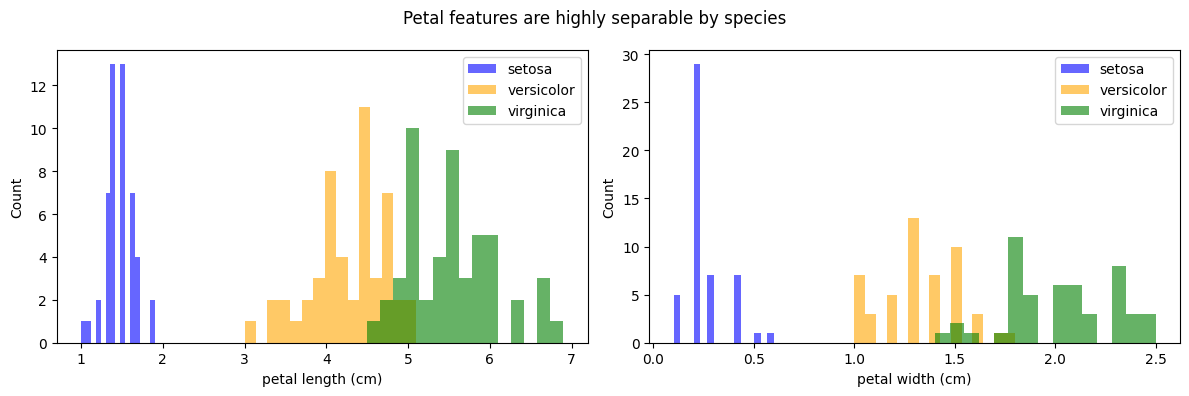

In [21]:
# Visualize feature distributions by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, ax in enumerate(axes):
    feature = iris.feature_names[i + 2]  # petal features
    for species, color in zip(iris.target_names, ['blue', 'orange', 'green']):
        mask = df['species'] == species
        ax.hist(df.loc[mask, feature], bins=15, alpha=0.6, label=species, color=color)
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Petal features are highly separable by species')
plt.tight_layout()
plt.show()

# Notice: setosa (blue) is easy to separate. versicolor vs virginica overlap a bit.
# This is the kind of insight that guides model choice.

In [22]:
# Step 3: Train/test split
# NEVER train and evaluate on the same data — you'd be cheating
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% held out for testing
    random_state=42,   # reproducibility
    stratify=y         # maintain class proportions in both splits
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')
print(f'Train class dist: {np.bincount(y_train)}')
print(f'Test class dist:  {np.bincount(y_test)}')

Training samples: 120
Test samples:     30
Train class dist: [40 40 40]
Test class dist:  [10 10 10]


In [23]:
# Step 4: Scale features
# Many models are sensitive to feature scale.
# StandardScaler: transforms each feature to mean=0, std=1
# Fit ONLY on training data, then transform both sets.
# (If you fit on test data too, you're leaking future information)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_test_scaled  = scaler.transform(X_test)        # transform only

print('Before scaling — feature means:', X_train.mean(axis=0).round(2))
print('After scaling  — feature means:', X_train_scaled.mean(axis=0).round(10))
print('After scaling  — feature stds: ', X_train_scaled.std(axis=0).round(2))

Before scaling — feature means: [5.84 3.05 3.77 1.2 ]
After scaling  — feature means: [-0. -0.  0.  0.]
After scaling  — feature stds:  [1. 1. 1. 1.]


In [25]:
# Step 5: Train a Logistic Regression model
# Despite the name, it's a classifier.
# Under the hood: computes X @ weights + bias, squashes through sigmoid, outputs probabilities

model = LogisticRegression(random_state=42, max_iter=200)
model.fit(X_train_scaled, y_train)

print('Model trained.')
print('Learned weights shape:', model.coef_.shape)   # (3 classes, 4 features)
print('Learned weights:')
print(pd.DataFrame(model.coef_, 
                   columns=iris.feature_names, 
                   index=iris.target_names).round(3))

Model trained.
Learned weights shape: (3, 4)
Learned weights:
            sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
setosa                 -1.089             1.024             -1.799            -1.686
versicolor              0.536            -0.360             -0.204            -0.808
virginica               0.553            -0.664              2.003             2.494


In [26]:
# Step 6: Evaluate
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy:.2%}\n')

# Classification report: precision, recall, f1-score per class
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Test Accuracy: 93.33%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



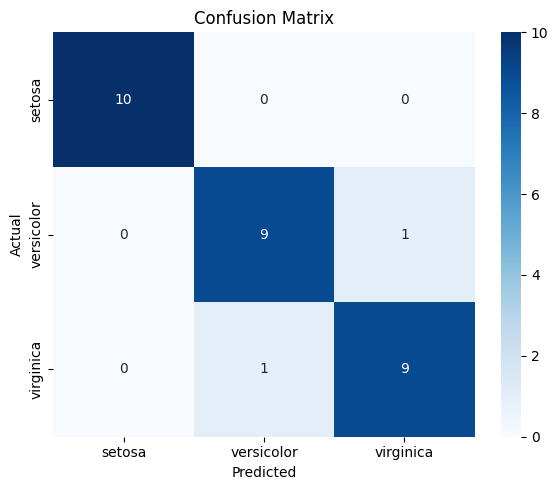

In [28]:
# Confusion matrix — see exactly where the model makes mistakes
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Diagonal = correct predictions
# Off-diagonal = errors. Where does it confuse versicolor vs virginica?

In [29]:
# Predict probabilities (not just class labels)
# This is often more useful than hard predictions
probs = model.predict_proba(X_test_scaled[:5])
prob_df = pd.DataFrame(probs, columns=iris.target_names).round(3)
prob_df['predicted'] = [iris.target_names[i] for i in y_pred[:5]]
prob_df['actual']    = [iris.target_names[i] for i in y_test[:5]]
print('Prediction probabilities for first 5 test samples:')
print(prob_df)

Prediction probabilities for first 5 test samples:
   setosa  versicolor  virginica   predicted      actual
0   0.979       0.021      0.000      setosa      setosa
1   0.004       0.369      0.627   virginica   virginica
2   0.149       0.842      0.009  versicolor  versicolor
3   0.095       0.895      0.010  versicolor  versicolor
4   0.988       0.012      0.000      setosa      setosa


---
## Part 3 — Second Model: Breast Cancer Dataset

Now do it yourself on a more realistic binary classification task.
Same workflow — but now try two models and compare them.

In [30]:
# Load dataset
cancer = load_breast_cancer()
X2 = cancer.data
y2 = cancer.target

print('Features:', cancer.feature_names[:5], '...')  # 30 features
print('Classes: ', cancer.target_names)              # malignant=0, benign=1
print('Dataset shape:', X2.shape)
print('Class distribution:', np.bincount(y2))

Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness'] ...
Classes:  ['malignant' 'benign']
Dataset shape: (569, 30)
Class distribution: [212 357]


In [31]:
# YOUR TURN: complete the ML workflow
# 1. Split into train/test (20% test, stratify=y2, random_state=42)
# 2. Scale features
# 3. Train a LogisticRegression AND a DecisionTreeClassifier
# 4. Compare accuracy on the test set

# Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Scale
scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s  = scaler2.transform(X2_test)

# Train both models
lr = LogisticRegression(random_state=42, max_iter=1000)
dt = DecisionTreeClassifier(random_state=42)

lr.fit(X2_train_s, y2_train)
dt.fit(X2_train_s, y2_train)

# Compare
lr_acc = accuracy_score(y2_test, lr.predict(X2_test_s))
dt_acc = accuracy_score(y2_test, dt.predict(X2_test_s))

print(f'Logistic Regression accuracy: {lr_acc:.2%}')
print(f'Decision Tree accuracy:       {dt_acc:.2%}')

Logistic Regression accuracy: 98.25%
Decision Tree accuracy:       91.23%


In [32]:
# Which model won? Why might one outperform the other?
# 
# DecisionTree often overfits — it memorizes training data.
# Try: add max_depth=5 to DecisionTreeClassifier and rerun.
# Notice how constraining the tree affects test accuracy.
#
# This is the bias-variance tradeoff in action.

dt_limited = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_limited.fit(X2_train_s, y2_train)
dt_lim_acc = accuracy_score(y2_test, dt_limited.predict(X2_test_s))

print(f'Decision Tree (depth=5) accuracy: {dt_lim_acc:.2%}')
print(f'Original DT accuracy:             {dt_acc:.2%}')
print(f'Logistic Regression accuracy:     {lr_acc:.2%}')

Decision Tree (depth=5) accuracy: 92.11%
Original DT accuracy:             91.23%
Logistic Regression accuracy:     98.25%


In [33]:
# Print full report for the best model
best_model = lr if lr_acc >= dt_lim_acc else dt_limited
best_name  = 'Logistic Regression' if lr_acc >= dt_lim_acc else 'Decision Tree (depth=5)'

y2_pred = best_model.predict(X2_test_s)
print(f'Best model: {best_name}\n')
print(classification_report(y2_test, y2_pred, target_names=cancer.target_names))

Best model: Logistic Regression

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



---
## Reflection

Before you close this notebook, answer these in a comment or a markdown cell:

1. What is a matrix in the context of a dataset? What are rows? What are columns?
2. Why do we scale features before training? What would happen if we didn't?
3. Why do we keep a test set separate from training data?
4. The DecisionTree with unlimited depth had different accuracy than with max_depth=5. What does that tell you?
5. In the logistic regression, `model.coef_` had shape `(3, 4)`. Why 3 and 4? What does each number mean?

**Write your answers below — this is how you solidify the knowledge.**

In [ ]:
# Your answers here:
# 1.
# 2.
# 3.
# 4.
# 5.

---
## Extension Challenges (optional, do when comfortable)

- **Easy:** Load a third dataset (`from sklearn.datasets import load_wine`) and repeat the full workflow.
- **Medium:** Implement the dot-product prediction (`X @ weights + bias`) manually, then verify your output matches `model.predict_proba()` on the Iris test set.
- **Hard:** Implement StandardScaler from scratch using only NumPy (no sklearn). Verify it matches sklearn's output.